# Vehicle Price Model KPI Report

## Executive Summary

This notebook rebuilds the model-output readout from the saved artifacts produced by `ML/Price_ML_Models.py` and `ML/Time_Series_Price.py`. It is intended to be rerun after model training so the KPI tables, segment checks, and forecast coverage update from the latest JSON/CSV outputs.


In [30]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "ML":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "MODELS_OUTPUT"
CURRENT_REPORT_PATH = OUTPUT_DIR / "model_report.json"
COHORT_REPORT_PATH = OUTPUT_DIR / "cohort_depreciation_model_report.json"
FORECAST_PATH = OUTPUT_DIR / "cohort_future_forecasts.csv"

def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing required report: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

current_report = load_json(CURRENT_REPORT_PATH)
cohort_report = load_json(COHORT_REPORT_PATH)
forecast_df = pd.read_csv(FORECAST_PATH, parse_dates=["observed_week_start", "forecast_date"]) if FORECAST_PATH.exists() else pd.DataFrame()


In [31]:
def money(value):
    if pd.isna(value):
        return "n/a"
    return f"${value:,.0f}"

def pct(value, digits=1):
    if pd.isna(value):
        return "n/a"
    return f"{value:.{digits}%}"

def horizon_days_from_target(target: str) -> int:
    try:
        return int(str(target).split("_")[-1].removesuffix("d"))
    except Exception:
        return -1

best_model = current_report["recommended_model"]
best_metrics = current_report["models"][best_model]
cohort_models = cohort_report.get("models", {})
trained_cohort_models = {
    name: model for name, model in cohort_models.items()
    if not model.get("skipped") and model.get("metrics")
}
skipped_cohort_models = {
    name: model for name, model in cohort_models.items()
    if model.get("skipped")
}
cohort_summary_rows = []
for target, model in trained_cohort_models.items():
    metrics = model.get("metrics", {})
    cohort_summary_rows.append(
        {
            "target": target,
            "horizon_days": horizon_days_from_target(target),
            "future_price_mae": metrics.get("future_price_mae"),
            "future_price_wape": metrics.get("future_price_wape"),
            "skill_vs_naive": metrics.get("future_price_mae_skill_vs_naive"),
            "depreciation_mae_pct_points": metrics.get("depreciation_mae_pct_points"),
            "bias_dollars": metrics.get("future_price_bias"),
            "depreciation_r2": metrics.get("depreciation_r2"),
        }
    )
cohort_summary = pd.DataFrame(cohort_summary_rows)
best_cohort = (
    cohort_summary.sort_values(["skill_vs_naive", "future_price_wape"], ascending=[False, True]).iloc[0]
    if not cohort_summary.empty
    else None
)
max_forecast_date = cohort_report.get("max_forecast_date")
last_observed_week = cohort_report.get("last_observed_week")

summary_lines = [
    f"- **Current-price winner:** `{best_model}` with MAE {money(best_metrics.get('mae'))}, RMSE {money(best_metrics.get('rmse'))}, MAPE {pct(best_metrics.get('mape'))}, and R2 {best_metrics.get('r2', np.nan):.3f}.",
    f"- **Validation design:** {current_report['row_counts']['train_rows']:,} train rows and {current_report['row_counts']['test_rows']:,} test rows with VIN overlap of {current_report['split']['vin_overlap']}.",
    f"- **Cohort forecast coverage:** latest observed cohort week is {last_observed_week}; saved forecasts extend to {max_forecast_date}.",
]
if best_cohort is not None:
    summary_lines.append(
        "- **Best time-series KPI:** "
        f"`{best_cohort['target']}` has the strongest skill vs no-change at {pct(best_cohort['skill_vs_naive'])}, "
        f"with future-price MAE {money(best_cohort['future_price_mae'])} and WAPE {pct(best_cohort['future_price_wape'])}."
    )
if skipped_cohort_models:
    skipped = ", ".join(f"`{target}` ({model.get('complete_rows', 0):,} complete rows)" for target, model in skipped_cohort_models.items())
    summary_lines.append(f"- **Long-horizon caveat:** direct models were skipped where labeled history is too sparse: {skipped}. Recursive forecast rows are marked separately in the forecast CSV.")

display(Markdown("\n".join(summary_lines)))


- **Current-price winner:** `Advanced_LightGBM` with MAE $1,935, RMSE $7,273, MAPE 7.5%, and R2 0.922.
- **Validation design:** 2,679,252 train rows and 669,813 test rows with VIN overlap of 0.
- **Cohort forecast coverage:** latest observed cohort week is 2026-06-29; saved forecasts extend to 2027-06-29.
- **Best time-series KPI:** `target_depreciation_pct_180d` has the strongest skill vs no-change at 13.9%, with future-price MAE $2,809 and WAPE 7.6%.

## Context & Methods

The KPI set follows common regression and forecast-evaluation practice:

- **MAE** is the primary business KPI because it is measured in dollars and is easy to interpret for vehicle pricing decisions.
- **RMSE** is retained because it penalizes large misses more heavily than MAE.
- **MAPE/WAPE/RMSLE** provide relative-error views for mixed price bands; MAPE is useful here because prices are positive, but it should not be the only KPI.
- **R2** is a model-fit signal, not a business KPI by itself.
- **Bias and naive-baseline skill** matter for time-series forecasts because a forecast can be low-error on average while still consistently overpricing or underpricing.
- **Segment MAE** by price band, high-value status, make, and model year checks whether the headline model hides weak slices.

Reference notes: scikit-learn's model-evaluation guide recommends choosing metrics around the prediction objective and includes MAE, RMSE, RMSLE, MAPE, and R2 for regression. Forecasting references such as Hyndman and Athanasopoulos emphasize comparing forecasts against simple baselines and using scale-aware accuracy measures where possible.


In [32]:
metric_contract = pd.DataFrame(
    [
        {"KPI": "MAE", "Where used": "Current price and forecast future price", "Why it matters": "Average dollar miss; easiest business interpretation", "Direction": "Lower is better"},
        {"KPI": "RMSE", "Where used": "Current price and forecast future price", "Why it matters": "Penalizes large misses and outlier errors", "Direction": "Lower is better"},
        {"KPI": "MAPE / WAPE", "Where used": "Relative price error", "Why it matters": "Compares misses across different price levels", "Direction": "Lower is better"},
        {"KPI": "RMSLE", "Where used": "Current price", "Why it matters": "Tracks multiplicative error on skewed positive prices", "Direction": "Lower is better"},
        {"KPI": "R2", "Where used": "Model comparison", "Why it matters": "Explained variance; useful but not sufficient alone", "Direction": "Higher is better"},
        {"KPI": "Skill vs naive", "Where used": "Cohort forecasts", "Why it matters": "Shows whether the model beats a no-change price forecast", "Direction": "Higher is better"},
        {"KPI": "Bias", "Where used": "Cohort forecasts", "Why it matters": "Flags systematic overpricing or underpricing", "Direction": "Closer to zero is better"},
        {"KPI": "Segment MAE", "Where used": "Price bands, high-value, make, year", "Why it matters": "Prevents average performance from hiding weak cohorts", "Direction": "Lower is better"},
    ]
)
metric_contract


,KPI,Where used,Why it matters,Direction
0,MAE,Current price and forecast future price,Average dollar miss; easiest business interpre...,Lower is better
1,RMSE,Current price and forecast future price,Penalizes large misses and outlier errors,Lower is better
2,MAPE / WAPE,Relative price error,Compares misses across different price levels,Lower is better
3,RMSLE,Current price,Tracks multiplicative error on skewed positive...,Lower is better
4,R2,Model comparison,Explained variance; useful but not sufficient ...,Higher is better
5,Skill vs naive,Cohort forecasts,Shows whether the model beats a no-change pric...,Higher is better
6,Bias,Cohort forecasts,Flags systematic overpricing or underpricing,Closer to zero is better
7,Segment MAE,"Price bands, high-value, make, year",Prevents average performance from hiding weak ...,Lower is better


## Current-Price Model Results

The current-price report is generated by `ML/Price_ML_Models.py` and saved as `MODELS_OUTPUT/model_report.json`. The leaderboard below ranks models by MAE, with RMSE, MAPE, RMSLE, and R2 retained for model-quality context.


In [33]:
current_rows = []
fit_metadata = current_report.get("model_fit_metadata", {})
for model_name, metrics in current_report["models"].items():
    fit_info = fit_metadata.get(model_name, {})
    current_rows.append(
        {
            "model": model_name,
            "mae": metrics.get("mae"),
            "rmse": metrics.get("rmse"),
            "mape": metrics.get("mape"),
            "rmsle": metrics.get("rmsle"),
            "r2": metrics.get("r2"),
            "fit_rows": fit_info.get("final_fit_rows"),
            "fit_strategy": fit_info.get("final_fit_strategy"),
        }
    )

current_model_kpis = pd.DataFrame(current_rows).sort_values("mae")
current_model_kpis.style.format(
    {
        "mae": "${:,.0f}",
        "rmse": "${:,.0f}",
        "mape": "{:.1%}",
        "rmsle": "{:.3f}",
        "r2": "{:.3f}",
        "fit_rows": "{:,.0f}",
    },
    na_rep="",
)


,model,mae,rmse,mape,rmsle,r2,fit_rows,fit_strategy
2,Advanced_LightGBM,"$1,935","$7,273",7.5%,0.130,0.922,"2,679,252",full_training_split
4,Segmented_HighValue_LightGBM,"$2,066","$6,400",7.9%,0.134,0.939,"2,679,252",full_training_split
3,Tree_RandomForest,"$2,974","$11,402",10.7%,0.164,0.807,"300,000",representative_bounded_fit
0,Readable_Ridge,"$5,964","$148,611",13.6%,0.191,-31.734,"2,679,252",full_training_split
1,Readable_ElasticNet,"$5,988","$150,999",13.6%,0.191,-32.794,"2,679,252",full_training_split


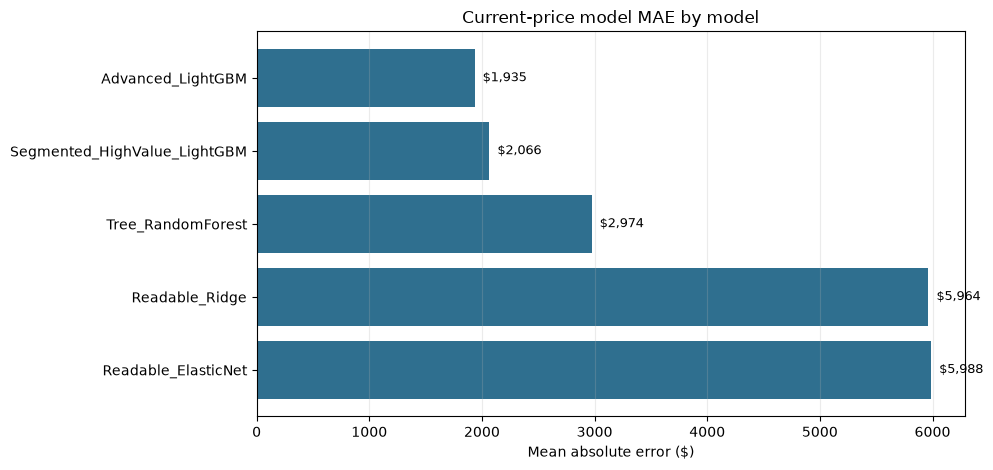

In [34]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = current_model_kpis.sort_values("mae", ascending=True)
ax.barh(plot_df["model"], plot_df["mae"], color="#2f6f8f")
ax.set_title("Current-price model MAE by model")
ax.set_xlabel("Mean absolute error ($)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
for idx, value in enumerate(plot_df["mae"]):
    ax.text(value, idx, f"  ${value:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Feature Weights And Fit Footprint

The simple-model rows expose signed coefficients after preprocessing and scaling. Tree-family rows expose model-native feature importance, which is useful for ranking variables but should not be read as a causal effect.

In [35]:
def extract_weights_from_artifact(model_name: str, top_n: int = 40) -> list[dict]:
    path = OUTPUT_DIR / f"{model_name}.joblib"
    if not path.exists():
        return []
    model = joblib.load(path)
    if "preprocessor" not in model.named_steps or "model" not in model.named_steps:
        return []
    estimator = getattr(model.named_steps["model"], "regressor_", model.named_steps["model"])
    weight_type = "feature_importance"
    if hasattr(estimator, "coef_"):
        weights = np.ravel(estimator.coef_).astype(float)
        weight_type = "coefficient"
    elif hasattr(estimator, "feature_importances_"):
        weights = np.ravel(estimator.feature_importances_).astype(float)
    elif hasattr(estimator, "global_regressor_") and hasattr(estimator.global_regressor_, "feature_importances_"):
        weights = np.ravel(estimator.global_regressor_.feature_importances_).astype(float)
        weight_type = "global_feature_importance"
    else:
        return []
    try:
        feature_names = list(model.named_steps["preprocessor"].get_feature_names_out())
    except Exception:
        feature_names = [f"feature_{idx}" for idx in range(len(weights))]
    if len(feature_names) != len(weights):
        feature_names = [f"feature_{idx}" for idx in range(len(weights))]
    rows = [
        {
            "model": model_name,
            "feature": feature,
            "weight": float(weight),
            "abs_weight": abs(float(weight)),
            "weight_type": weight_type,
        }
        for feature, weight in zip(feature_names, weights)
    ]
    return sorted(rows, key=lambda row: row["abs_weight"], reverse=True)[:top_n]

feature_profile = current_report.get("feature_space_profile", {})
if feature_profile:
    display(
        pd.DataFrame(
            [
                {"metric": "raw pandas training frame", "value": f"{feature_profile.get('raw_pandas_training_frame_mb', np.nan):,.0f} MB"},
                {"metric": "profiled transformed shape", "value": str(tuple(feature_profile.get("transformed_shape_on_profile", [])))},
                {"metric": "transformed dtype", "value": feature_profile.get("transformed_dtype")},
                {"metric": "projected full transformed matrix", "value": f"{feature_profile.get('projected_full_training_matrix_memory_mb', np.nan) / 1024:,.2f} GB"},
            ]
        )
    )

weight_rows = []
saved_weights = current_report.get("model_feature_weights", {})
for model_name in ["Readable_Ridge", "Readable_ElasticNet", best_model]:
    rows = saved_weights.get(model_name) or extract_weights_from_artifact(model_name)
    for row in rows[:20]:
        row = dict(row)
        row.setdefault("model", model_name)
        weight_rows.append(row)

current_feature_weights = pd.DataFrame(weight_rows)
if current_feature_weights.empty:
    display(Markdown("No saved feature weights were found. Rerun `ML/Price_ML_Models.py` after the latest script update."))
else:
    display(
        current_feature_weights[["model", "feature", "weight", "abs_weight", "weight_type"]]
        .sort_values(["model", "abs_weight"], ascending=[True, False])
        .style.format({"weight": "{:.4g}", "abs_weight": "{:.4g}"})
    )


,metric,value
0,raw pandas training frame,"11,067 MB"
1,profiled transformed shape,"(200000, 327)"
2,transformed dtype,float32
3,projected full transformed matrix,3.26 GB


,model,feature,weight,abs_weight,weight_type
40,Advanced_LightGBM,cat_high__0,6447,6447,feature_importance
41,Advanced_LightGBM,num__distance,5728,5728,feature_importance
42,Advanced_LightGBM,cat_high__1,5096,5096,feature_importance
43,Advanced_LightGBM,cat_high__13,4321,4321,feature_importance
44,Advanced_LightGBM,num__locationCode,4304,4304,feature_importance
45,Advanced_LightGBM,num__mileage,4106,4106,feature_importance
46,Advanced_LightGBM,cat_high__9,3612,3612,feature_importance
47,Advanced_LightGBM,num__miles_per_year,3585,3585,feature_importance
48,Advanced_LightGBM,num__title_length,3112,3112,feature_importance
49,Advanced_LightGBM,num__mileage_age_interaction,2911,2911,feature_importance


## Segment Checks

The best model should be judged on the segments that matter operationally, not only on the global average. These tables use the segment metrics already saved in the current-price model report.


In [36]:
best_segment_metrics = current_report["models"][best_model].get("segment_metrics", {})

def segment_table(segment_name: str, min_rows: int = 1) -> pd.DataFrame:
    rows = []
    for segment_value, stats in best_segment_metrics.get(segment_name, {}).items():
        rows.append(
            {
                "segment": segment_value,
                "rows": stats.get("rows", 0),
                "mae": stats.get("mae", np.nan),
            }
        )
    if not rows:
        return pd.DataFrame(columns=["segment", "rows", "mae"])
    return (
        pd.DataFrame(rows)
        .query("rows >= @min_rows")
        .sort_values("mae", ascending=False)
        .reset_index(drop=True)
    )

price_band_check = segment_table("price_band")
high_value_check = segment_table("is_high_value")
make_check = segment_table("nhtsa_Make", min_rows=100).head(12)

display(Markdown("### Price Band MAE"))
display(price_band_check.style.format({"mae": "${:,.0f}"}))
display(Markdown("### High-Value Slice"))
display(high_value_check.style.format({"mae": "${:,.0f}"}))
display(Markdown("### Highest-MAE Makes With At Least 100 Test Rows"))
display(make_check.style.format({"mae": "${:,.0f}"}))


### Price Band MAE

,segment,rows,mae
0,150k_plus,3020,"$42,633"
1,100k_150k,3281,"$13,201"
2,50k_100k,57102,"$3,909"
3,25k_50k,290031,"$1,653"
4,under_25k,316379,"$1,333"


### High-Value Slice

,segment,rows,mae
0,high_value,3022,"$42,639"
1,everyday,666791,"$1,751"


### Highest-MAE Makes With At Least 100 Test Rows

,segment,rows,mae
0,FERRARI,680,"$54,566"
1,LAMBORGHINI,545,"$44,484"
2,MCLAREN,238,"$34,918"
3,PORSCHE,8573,"$9,061"
4,MASERATI,945,"$4,661"
5,JAGUAR,1379,"$3,080"
6,CADILLAC,10100,"$2,746"
7,BMW,26769,"$2,587"
8,GENESIS,3279,"$2,391"
9,RAM,25208,"$2,390"


## Cohort Forecast Model Results

The time-series script trains cohort-level depreciation models by make, model, model year, and trim proxy. Direct horizon models require enough historical rows where the future target is already known. When direct long-horizon labels are too sparse, the script records a skip reason instead of failing and still writes one-year recursive projections from the shortest trained horizon model.


In [37]:
cohort_rows = []
for target, model in cohort_report.get("models", {}).items():
    metrics = model.get("metrics", {})
    cohort_rows.append(
        {
            "target": target,
            "horizon_days": horizon_days_from_target(target),
            "status": "skipped" if model.get("skipped") else "trained",
            "complete_rows": model.get("complete_rows"),
            "train_rows": model.get("train_rows"),
            "test_rows": model.get("test_rows"),
            "future_price_mae": metrics.get("future_price_mae"),
            "future_price_wape": metrics.get("future_price_wape"),
            "naive_mae": metrics.get("naive_no_change_future_price_mae"),
            "skill_vs_naive": metrics.get("future_price_mae_skill_vs_naive"),
            "beats_naive": metrics.get("future_price_mae_skill_vs_naive", np.nan) > 0,
            "depreciation_mae_pct_points": metrics.get("depreciation_mae_pct_points"),
            "bias_dollars": metrics.get("future_price_bias"),
            "depreciation_r2": metrics.get("depreciation_r2"),
            "skip_reason": model.get("skipped") or model.get("validation_warning"),
        }
    )

cohort_kpis = pd.DataFrame(cohort_rows).sort_values(["status", "skill_vs_naive"], ascending=[True, False])
if not cohort_summary.empty:
    best = cohort_summary.sort_values(["skill_vs_naive", "future_price_wape"], ascending=[False, True]).iloc[0]
    display(Markdown(f"**Best validated time-series horizon by skill vs naive:** `{best['target']}` ({int(best['horizon_days'])} days), skill {pct(best['skill_vs_naive'])}, WAPE {pct(best['future_price_wape'])}, MAE {money(best['future_price_mae'])}."))
cohort_kpis.style.format(
    {
        "future_price_mae": "${:,.0f}",
        "future_price_wape": "{:.1%}",
        "naive_mae": "${:,.0f}",
        "skill_vs_naive": "{:.1%}",
        "depreciation_mae_pct_points": "{:.2f}",
        "bias_dollars": "${:,.0f}",
        "depreciation_r2": "{:.3f}",
    },
    na_rep="",
)


**Best validated time-series horizon by skill vs naive:** `target_depreciation_pct_180d` (180 days), skill 13.9%, WAPE 7.6%, MAE $2,809.

,target,horizon_days,status,complete_rows,train_rows,test_rows,future_price_mae,future_price_wape,naive_mae,skill_vs_naive,beats_naive,depreciation_mae_pct_points,bias_dollars,depreciation_r2,skip_reason
2,target_depreciation_pct_180d,180,trained,73967,41645,11096,"$2,809",7.6%,"$3,261",13.9%,True,8.48,$-921,0.380,
0,target_depreciation_pct_30d,30,trained,103889,84801,11019,"$2,129",5.5%,"$2,433",12.5%,True,6.60,$-502,0.401,
1,target_depreciation_pct_90d,90,trained,90701,73969,760,"$2,177",5.4%,"$2,260",3.7%,True,6.28,$-858,0.394,
3,target_depreciation_pct_365d,365,trained,50018,18680,7626,"$6,752",19.6%,"$3,664",-84.2%,False,21.22,"$5,060",-4.143,


## Time-Series Feature Importance

These rows use the best validated cohort horizon from the time-series report. They show model-native LightGBM importance at the cohort-week grain.

In [38]:
def cohort_feature_importance_for_target(target: str, top_n: int = 25) -> pd.DataFrame:
    model_report = cohort_report.get("models", {}).get(target, {})
    rows = model_report.get("feature_importance") or []
    if not rows and model_report.get("artifact"):
        path = OUTPUT_DIR / model_report["artifact"]
        if path.exists():
            model = joblib.load(path)
            estimator = model.named_steps.get("model")
            if hasattr(estimator, "feature_importances_"):
                weights = np.ravel(estimator.feature_importances_).astype(float)
                try:
                    feature_names = list(model.named_steps["preprocessor"].get_feature_names_out())
                except Exception:
                    feature_names = [f"feature_{idx}" for idx in range(len(weights))]
                if len(feature_names) != len(weights):
                    feature_names = [f"feature_{idx}" for idx in range(len(weights))]
                rows = [
                    {"feature": feature, "importance": float(weight), "abs_weight": abs(float(weight)), "weight_type": "feature_importance"}
                    for feature, weight in zip(feature_names, weights)
                ]
    return pd.DataFrame(rows).sort_values("abs_weight", ascending=False).head(top_n) if rows else pd.DataFrame()

if best_cohort is None:
    display(Markdown("No trained cohort model metrics were found."))
else:
    best_target = best_cohort["target"]
    cohort_feature_importance = cohort_feature_importance_for_target(best_target)
    if cohort_feature_importance.empty:
        display(Markdown("No feature importance was found for the best cohort model. Rerun `ML/Time_Series_Price.py` after the latest script update."))
    else:
        display(Markdown(f"### Top drivers for `{best_target}`"))
        display(cohort_feature_importance[["feature", "importance", "abs_weight", "weight_type"]].style.format({"importance": "{:,.0f}", "abs_weight": "{:,.0f}"}))


### Top drivers for `target_depreciation_pct_180d`

,feature,importance,abs_weight,weight_type
0,cohort_week_number,"1,511","1,511",feature_importance
1,price_index_vs_cohort_first,"1,441","1,441",feature_importance
2,avg_vehicle_age_months,"1,316","1,316",feature_importance
3,cohort_age_weeks,"1,285","1,285",feature_importance
4,trim_proxy,"1,223","1,223",feature_importance
5,cohort_first_median_price,"1,173","1,173",feature_importance
6,market_median_price,"1,091","1,091",feature_importance
7,lag_price_index_1,997,997,feature_importance
8,engine_hp,929,929,feature_importance
9,rolling_median_price_4,926,926,feature_importance


In [39]:
if forecast_df.empty:
    display(Markdown("No forecast CSV was found. Run `ML/Time_Series_Price.py` to generate `cohort_future_forecasts.csv`."))
else:
    coverage = pd.DataFrame(
        [
            {"metric": "forecast rows", "value": f"{len(forecast_df):,}"},
            {"metric": "cohorts", "value": f"{forecast_df[['make', 'model', 'model_year', 'trim_proxy']].drop_duplicates().shape[0]:,}"},
            {"metric": "last observed week", "value": str(forecast_df["observed_week_start"].max().date())},
            {"metric": "max forecast date", "value": str(forecast_df["forecast_date"].max().date())},
            {"metric": "max horizon days", "value": f"{forecast_df['forecast_horizon_days'].max():,}"},
        ]
    )
    display(coverage)
    display(
        forecast_df.groupby(["forecast_method", "forecast_horizon_days"], as_index=False)
        .size()
        .rename(columns={"size": "rows"})
        .sort_values(["forecast_horizon_days", "forecast_method"])
        .tail(20)
    )


,metric,value
0,forecast rows,"154,880"
1,cohorts,"38,720"
2,last observed week,2026-06-29
3,max forecast date,2027-06-29
4,max horizon days,365


,forecast_method,forecast_horizon_days,rows
1,direct_30d_model,30,38720
3,direct_90d_model,90,38720
0,direct_180d_model,180,38720
2,direct_365d_model,365,38720


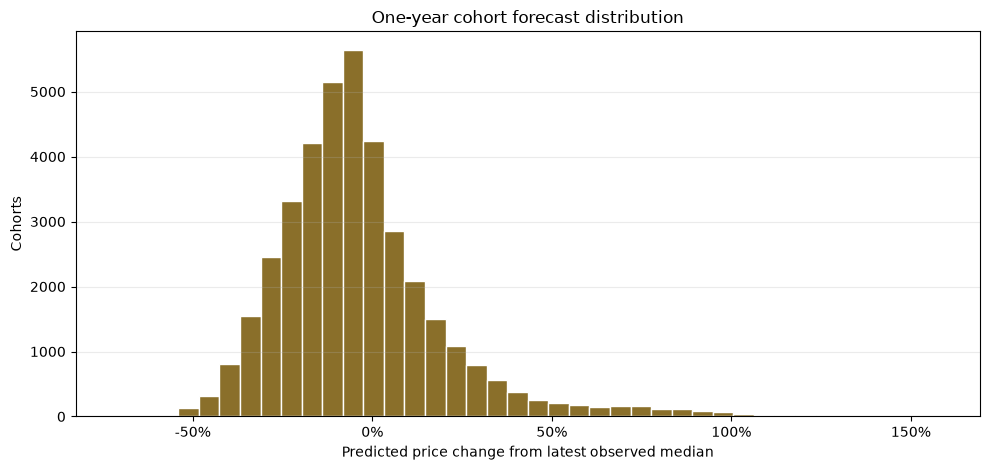

,predicted_depreciation_pct
count,3872000.0%
mean,-3.7%
std,23.5%
min,-71.2%
10%,-28.4%
25%,-18.1%
50%,-6.8%
75%,5.3%
90%,23.2%
max,157.8%


In [40]:
if not forecast_df.empty and forecast_df["forecast_horizon_days"].max() >= 365:
    one_year = forecast_df[forecast_df["forecast_horizon_days"].eq(forecast_df["forecast_horizon_days"].max())].copy()
    one_year["predicted_depreciation_pct"] = pd.to_numeric(one_year["predicted_depreciation_pct"], errors="coerce")
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.hist(one_year["predicted_depreciation_pct"].dropna(), bins=40, color="#8a6f2a", edgecolor="white")
    ax.set_title("One-year cohort forecast distribution")
    ax.set_xlabel("Predicted price change from latest observed median")
    ax.set_ylabel("Cohorts")
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    one_year_summary = one_year["predicted_depreciation_pct"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("predicted_depreciation_pct")
    display(one_year_summary.style.format("{:.1%}"))


## Takeaways

- The current-price model should be monitored primarily with MAE, RMSE, MAPE/RMSLE, and segment MAE. The best saved run currently favors the LightGBM model, but high-value and exotic segments remain materially harder than everyday-price vehicles.
- The cohort forecast model now reports baseline skill, WAPE, and bias in addition to depreciation error. Those KPIs make it clear whether a forecast beats a no-change baseline and whether it systematically overprices or underprices.
- Long-horizon direct forecasts depend on enough observed future labels. When the labeled history is not deep enough, direct 90/180/365-day models should be treated as unavailable rather than forced. The saved one-year projection is still useful as a directional scenario, but rows marked `recursive_*_model` should be read as extrapolated.
- The next model-quality improvement should be adding more historical price depth or lowering cohort sparsity, then rerunning the notebook to see whether direct 180-day and 365-day models become trainable and beat the naive no-change baseline.


## Sources

- scikit-learn, [Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- Hyndman and Athanasopoulos, [Forecasting: Principles and Practice, Evaluating point forecast accuracy](https://otexts.com/fpp3/accuracy.html)
- Hyndman and Koehler, [Another look at measures of forecast accuracy](https://robjhyndman.com/publications/another-look-at-measures-of-forecast-accuracy/)
